**Data Pipeline: E-commerce Global Sales Analysis**


Author:Zebidah Manyara

Date: March 6, 2026

Objective: To transform 1 million+ rows of raw transactional data into a cloud-synced executive dashboard for decision-making.

**The Business Challenge**


The raw dataset contains several critical data quality issues that prevent accurate reporting:

-Inconsistent Date Formats: Regional variations (MM/DD vs DD/MM) cause parsing errors.

-Missing Identifiers: Large volumes of missing Customer IDs threaten retention and churn analysis.

-Operational Noise: Negative quantities and zero-price entries skew total revenue figures

Phase 1: Extraction and Data Discovery


In this phase, we load the raw data and use visualization to map out the "missingness" of the dataset. This helps us decide which data to "impute" (fill in) and which to "drop."

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [16]:
df = pd.read_csv

In [17]:
df = pd.read_csv("Year 2009-2010.csv", encoding='latin1')

In [18]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [4]:
df.shape

(525461, 8)

In [5]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  str    
 1   StockCode    525461 non-null  str    
 2   Description  522533 non-null  str    
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  str    
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.3 MB


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [19]:
df = pd.read_csv("Year 2010-2011.csv", encoding='latin1')

In [20]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [21]:
df1 = pd.read_csv("Year 2009-2010.csv", encoding="latin1")
df2 = pd.read_csv("Year 2010-2011.csv", encoding="latin1")

data = pd.concat([df1, df2], ignore_index=True)

In [22]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [24]:
df.shape

(541910, 8)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [26]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [27]:
data["InvoiceDate"].min(), data["InvoiceDate"].max()

('1/10/2010 10:26', '9/9/2011 9:52')

In [28]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"], errors="coerce")

In [29]:
problem_dates = data[data["InvoiceDate"].isna()]
problem_dates

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [30]:
problem_dates.shape

(0, 8)

Remove missing customer IDs

In [31]:
df = df.dropna(subset=['Customer ID'])

Confirmation that there are no missing values

In [35]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [33]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Renaming columns according to snake casing for better readability and documentation

In [36]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [37]:
df.columns

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country'],
      dtype='str')

Create a Revenue column

In [39]:
df['revenue'] = df['quantity'] * df['price']

In [40]:
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


Total Revenue

In [46]:
df['revenue'].sum()

np.float64(8300083.813999999)

Top Selling Products

In [43]:
df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: quantity, dtype: int64

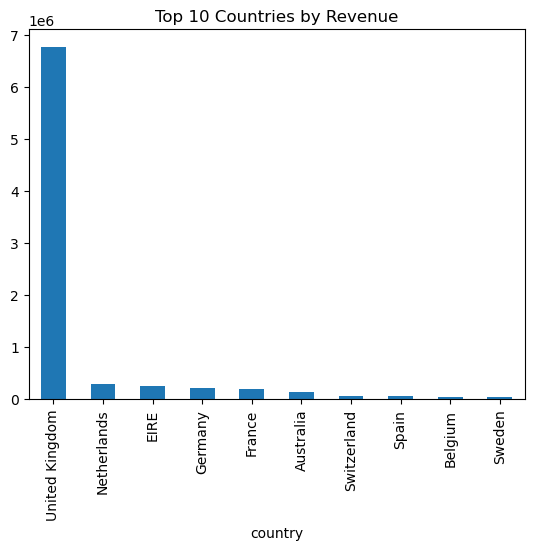

In [45]:
df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.show()

Top Customers

In [48]:
df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)

customer_id
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: revenue, dtype: float64

In [50]:
data.columns


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [51]:
data["Year"] = data["InvoiceDate"].dt.year
data["Month"] = data["InvoiceDate"].dt.month
data["Day"] = data["InvoiceDate"].dt.day

In [52]:
monthly_sales = data.groupby("Month")["Quantity"].sum()
monthly_sales

Month
1      684329
2      646391
3      841242
4      641069
5      744486
6      729876
7      693317
8      858002
9     1028079
10    1172261
11    1414142
12    1155298
Name: Quantity, dtype: int64

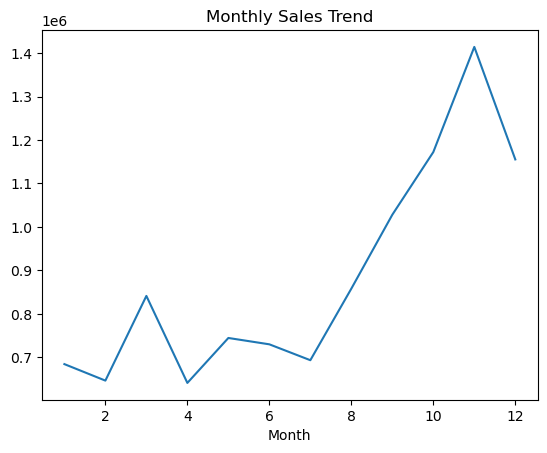

In [53]:
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

In [55]:
data[["InvoiceDate", "Year", "Month", "Day"]].head()

,InvoiceDate,Year,Month,Day
0,2009-12-01 07:45:00,2009,12,1
1,2009-12-01 07:45:00,2009,12,1
2,2009-12-01 07:45:00,2009,12,1
3,2009-12-01 07:45:00,2009,12,1
4,2009-12-01 07:45:00,2009,12,1


In [56]:
df.to_csv("cleaned_sales_data.csv", index=False)